###**TEORÍA DE PORTAFOLIOS**
Apuntes de: Alejandro Vargas Sanchez, PhD, CFA

alejandro.vargas@upb.edu

**1. Importamos las librerías**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
import seaborn as sns; sns.set_theme()

**2. Cargamos la serie de tiempo de precios de las acciones**

In [ ]:
df = pd.read_excel('Stock_price.xlsx', sheet_name = 'Stocks',
                   header=0, index_col=0, parse_dates=True,)

In [ ]:
df

,AAPL.OQ,F,TSLA.O,M,MSFT.O,MMM,T,DIS,GOOGL.O,AMZN.O,CAT,CSCO.O,C,DD,FDX,GM
Date,,,,,,,,,,,,,,,,
2020-10-15,120.71,7.148897,149.626517,6.27,219.66,141.363561,20.729609,127.36,77.7735,166.9325,165.04,39.97,43.61,59.28,282.11,32.59
2020-10-16,119.02,7.195806,146.556520,6.16,219.66,142.943743,20.638987,126.81,78.3850,163.6355,168.75,40.16,43.19,59.17,283.87,33.45
2020-10-19,115.98,7.120752,143.609856,6.10,214.22,141.756516,20.299158,124.23,76.4975,160.3605,167.53,39.30,42.90,58.44,281.97,33.35
2020-10-20,117.51,7.261479,140.646526,6.34,214.65,142.927021,20.208537,124.95,77.5540,160.8505,168.99,39.20,43.52,59.48,287.40,35.60
2020-10-21,116.87,7.364678,140.879859,6.52,214.80,141.438808,20.178329,126.63,79.2995,159.2470,167.40,39.06,43.01,58.66,282.28,35.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-09,254.04,11.500000,435.540000,17.28,522.40,152.880000,26.100000,110.99,241.5300,227.7400,500.36,69.96,95.92,77.84,237.00,55.92
2025-10-10,245.27,11.410000,413.490000,16.51,510.96,148.750000,25.870000,109.19,236.5700,216.3700,491.30,67.94,93.93,73.70,224.63,55.35
2025-10-13,247.66,11.540000,435.900000,17.45,514.05,151.100000,25.590000,110.27,244.1500,220.0700,504.76,67.46,96.10,75.95,229.65,55.62


**3. Calculamos los HPR en base a los precios diarios**

$HPR = \frac{P_1 + D_1 - P_0}{P_0}$

In [ ]:
r = df.pct_change().dropna()
r.name = 'asset_returns'

In [ ]:
r

,AAPL.OQ,F,TSLA.O,M,MSFT.O,MMM,T,DIS,GOOGL.O,AMZN.O,CAT,CSCO.O,C,DD,FDX,GM
Date,,,,,,,,,,,,,,,,
2020-10-16,-0.014000,0.006562,-0.020518,-0.017544,0.000000,0.011178,-0.004372,-0.004318,0.007863,-0.019750,0.022479,0.004754,-0.009631,-0.001856,0.006239,0.026388
2020-10-19,-0.025542,-0.010430,-0.020106,-0.009740,-0.024766,-0.008306,-0.016465,-0.020345,-0.024080,-0.020014,-0.007230,-0.021414,-0.006715,-0.012337,-0.006693,-0.002990
2020-10-20,0.013192,0.019763,-0.020635,0.039344,0.002007,0.008257,-0.004464,0.005796,0.013811,0.003056,0.008715,-0.002545,0.014452,0.017796,0.019257,0.067466
2020-10-21,-0.005446,0.014212,0.001659,0.028391,0.000699,-0.010412,-0.001495,0.013445,0.022507,-0.009969,-0.009409,-0.003571,-0.011719,-0.013786,-0.017815,0.004775
2020-10-22,-0.009583,0.045860,0.007453,0.075153,0.000419,0.009103,0.058383,0.007344,0.013033,-0.002681,0.013501,-0.006144,0.021855,0.013979,-0.022425,0.045848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-09,-0.015578,-0.020443,-0.007180,-0.024831,-0.004668,-0.020000,-0.005714,-0.008044,-0.012632,0.011189,-0.003505,-0.005261,-0.008066,-0.006763,-0.012212,-0.008511
2025-10-10,-0.034522,-0.007826,-0.050627,-0.044560,-0.021899,-0.027015,-0.008812,-0.016218,-0.020536,-0.049925,-0.018107,-0.028874,-0.020746,-0.053186,-0.052194,-0.010193
2025-10-13,0.009744,0.011394,0.054197,0.056935,0.006047,0.015798,-0.010823,0.009891,0.032041,0.017100,0.027397,-0.007065,0.023102,0.030529,0.022348,0.004878


**4. Importamos el risk kit de AVS**

In [ ]:
import avs_risk_kit as ark

**5. Utilizamos el risk kit para anualizar los rendimientos mensuales**

$R_{anualizado} = \left(1 + R_{diario}\right)^{252} - 1$

In [ ]:
er = ark.annualize_rets(r["2020":"2025"], 252)
cov = r["2020":"2025"].cov()*252

In [ ]:
er

,0
AAPL.OQ,0.156807
F,0.105111
TSLA.O,0.239069
M,0.234469
MSFT.O,0.185878
MMM,0.016636
T,0.047103
DIS,-0.025983
GOOGL.O,0.265273
AMZN.O,0.052684


**6. Calculamos la matriz de covarianzas**

In [ ]:
cov

,AAPL.OQ,F,TSLA.O,M,MSFT.O,MMM,T,DIS,GOOGL.O,AMZN.O,CAT,CSCO.O,C,DD,FDX,GM
AAPL.OQ,0.080846,0.038355,0.085361,0.048220,0.047556,0.023654,0.008776,0.033169,0.051011,0.057371,0.023716,0.029734,0.028857,0.035018,0.036213,0.033798
F,0.038355,0.156318,0.080486,0.089946,0.031819,0.036587,0.021726,0.049097,0.037950,0.041509,0.055459,0.031336,0.054818,0.054907,0.051446,0.112416
TSLA.O,0.085361,0.080486,0.375714,0.085425,0.066222,0.032568,0.001779,0.058130,0.075887,0.094627,0.046570,0.036107,0.058107,0.051486,0.054794,0.077352
M,0.048220,0.089946,0.085425,0.345791,0.033940,0.048532,0.018957,0.063804,0.047592,0.058558,0.062912,0.036981,0.072229,0.067069,0.059240,0.080423
MSFT.O,0.047556,0.031819,0.066222,0.033940,0.067400,0.019345,0.002282,0.030151,0.053831,0.061274,0.020249,0.026525,0.023157,0.026894,0.028549,0.028695
MMM,0.023654,0.036587,0.032568,0.048532,0.019345,0.076380,0.015156,0.028810,0.021808,0.025270,0.036650,0.024108,0.034498,0.040185,0.031618,0.036829
T,0.008776,0.021726,0.001779,0.018957,0.002282,0.015156,0.057603,0.017901,0.004576,0.005520,0.013061,0.012265,0.020240,0.015127,0.010791,0.019512
DIS,0.033169,0.049097,0.058130,0.063804,0.030151,0.028810,0.017901,0.092247,0.033488,0.044232,0.036316,0.026971,0.044934,0.039251,0.035034,0.049105
GOOGL.O,0.051011,0.037950,0.075887,0.047592,0.053831,0.021808,0.004576,0.033488,0.096337,0.068011,0.023909,0.028084,0.030509,0.032898,0.031940,0.035409
AMZN.O,0.057371,0.041509,0.094627,0.058558,0.061274,0.025270,0.005520,0.044232,0.068011,0.122722,0.027345,0.029913,0.034753,0.036886,0.041699,0.040553


Encontramos las correlaciones entre los rendimientos.

In [ ]:
corr = r["2020":"2025"].corr()

Presentamos un mapa de calor en base a los coeficientes de correlación, **Heat Map**.

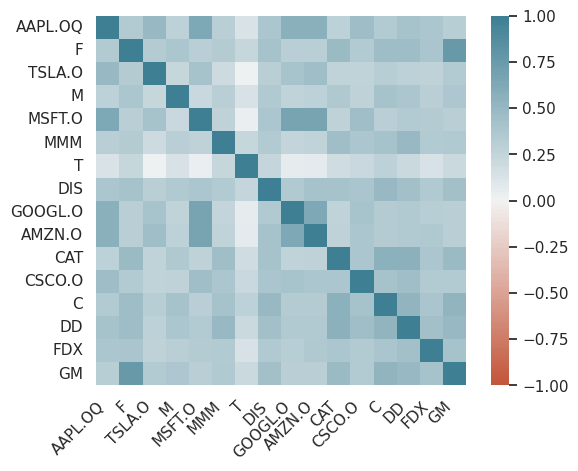

In [ ]:
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
);

**7. Cargamos datos sobre las tasas libre de riesgo**

In [ ]:
rf = pd.read_excel('3M_TBill.xlsx', sheet_name = 'TBill',
                   header=0, index_col=0, parse_dates=True,)

In [ ]:
rf

,3M_US_TBill
Date,
2020-10-15,0.104
2020-10-16,0.096
2020-10-19,0.096
2020-10-20,0.101
2020-10-21,0.096
...,...
2025-10-08,3.944
2025-10-09,3.954
2025-10-10,3.947


In [ ]:
rf = rf['3M_US_TBill']/100
rf.name = 'risk_free'
rf=pd.DataFrame(rf)

In [ ]:
rf

,risk_free
Date,
2020-10-15,0.00104
2020-10-16,0.00096
2020-10-19,0.00096
2020-10-20,0.00101
2020-10-21,0.00096
...,...
2025-10-08,0.03944
2025-10-09,0.03954
2025-10-10,0.03947


In [ ]:
# Calcular el promedio de la tasa libre de riesgo
rf = rf['risk_free'].mean()

# Mostrar el valor decimal
print("Tasa libre de riesgo (decimal):", float(rf))

# Mostrar el valor en porcentaje con 2 decimales
print("Tasa libre de riesgo (%):", round(rf * 100, 2), "%")

Tasa libre de riesgo (decimal): 0.0315366344
Tasa libre de riesgo (%): 3.15 %


**8. Graficamos la Frontera Eficiente**

La función te permite seleccionar graficar la línea de CML:

$E(R_p) = R_f + \frac{E(R_m) - R_f}{\sigma_m} \cdot \sigma_p$


El portafolio igualmente ponderado EW:

$w_i = \frac{1}{n}$


El portafolio de mínima varianza GMV:

$\text{Minimizar } \sigma_p^2 = \mathbf{w}^T \mathbf{C} \mathbf{w}$

<Axes: xlabel='Volatility'>

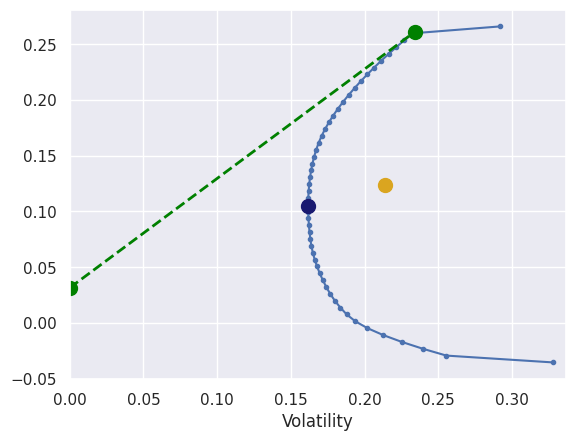

In [ ]:
ark.plot_ef(50, er, cov, show_cml=True, riskfree_rate=rf, show_ew=True, show_gmv=True)

**9. Calculamos el Sharpe Ratio para cada activo riesgoso**

In [ ]:
ark.sharpe_ratio(r, rf, 252)

,0
AAPL.OQ,0.427139
F,0.180397
TSLA.O,0.328225
M,0.334552
MSFT.O,0.576380
MMM,-0.052289
T,0.062867
DIS,-0.183633
GOOGL.O,0.730115
AMZN.O,0.058506


**10. Mediante el risk kit encontramos el portafolio óptimo que maximiza el Sharpe Ratio**

In [ ]:
ark.msr(rf, er, cov).round(3)

array([0.   , 0.   , 0.   , 0.   , 0.055, 0.   , 0.   , 0.   , 0.418,
       0.   , 0.527, 0.   , 0.   , 0.   , 0.   , 0.   ])

Graficamos el asset allocation óptimo

In [ ]:
optimal_w=np.array(ark.msr(rf, er, cov).round(6))
optimal_w

array([0.      , 0.      , 0.      , 0.      , 0.054984, 0.      ,
       0.      , 0.      , 0.417722, 0.      , 0.527293, 0.      ,
       0.      , 0.      , 0.      , 0.      ])

In [ ]:
RISKY_ASSET = df.columns.tolist()

In [ ]:
print("RISKY_ASSET =", RISKY_ASSET)

RISKY_ASSET = ['AAPL.OQ', 'F', 'TSLA.O', 'M', 'MSFT.O', 'MMM', 'T', 'DIS', 'GOOGL.O', 'AMZN.O', 'CAT', 'CSCO.O', 'C', 'DD', 'FDX', 'GM']


In [ ]:
optimal_w=pd.DataFrame({'Allocation':optimal_w}, RISKY_ASSET)
optimal_w

,Allocation
AAPL.OQ,0.000000
F,0.000000
TSLA.O,0.000000
M,0.000000
MSFT.O,0.054984
MMM,0.000000
T,0.000000
DIS,0.000000
GOOGL.O,0.417722
AMZN.O,0.000000


In [ ]:
optimal_w = optimal_w[optimal_w['Allocation'] > 0]
optimal_w

,Allocation
MSFT.O,0.054984
GOOGL.O,0.417722
CAT,0.527293


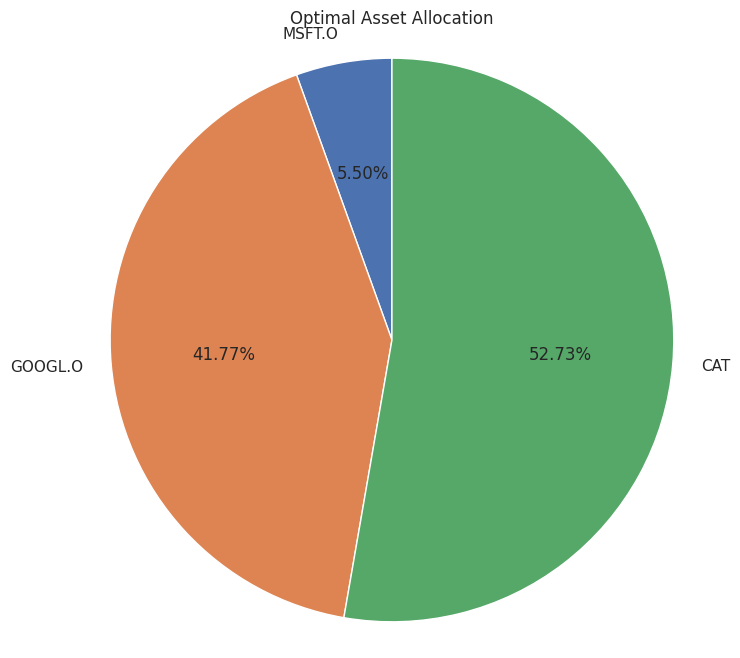

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))  # Increase the figure size to better accommodate labels
explode_values = [0.1 if x < 0.05 else 0 for x in optimal_w['Allocation']]  # Explode slices smaller than 5%
ax.pie(optimal_w['Allocation'], labels=optimal_w.index, startangle=90, autopct='%1.2f%%', explode=explode_values)
ax.axis('equal')  # Maintain the aspect ratio to ensure the pie chart is a circle

plt.title('Optimal Asset Allocation')
plt.show()

**11. Mediante el risk kit encontramos el portafolio de varianza mínima**

In [ ]:
ark.gmv(cov).round(3)

array([0.007, 0.   , 0.   , 0.   , 0.205, 0.093, 0.349, 0.004, 0.023,
       0.   , 0.077, 0.198, 0.   , 0.   , 0.043, 0.   ])

Se presenta la función que permite calcular los **Corner Portfolios**.

In [ ]:
ark.minimize_vol(0.1, er, cov)

array([4.99489037e-03, 2.57987811e-17, 0.00000000e+00, 0.00000000e+00,
       2.02603132e-01, 9.89172696e-02, 3.49923700e-01, 1.19812824e-02,
       1.70834928e-02, 0.00000000e+00, 6.58081996e-02, 1.99486395e-01,
       0.00000000e+00, 0.00000000e+00, 4.92016387e-02, 1.33393558e-18])

**12. Se presenta una lista de 10 portafolios en la frontera eficiente**

In [ ]:
ark.optimal_weights(10, er, cov)

[array([0.00000000e+00, 1.30451205e-14, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 5.48172618e-16, 7.69720163e-08,
        1.32949207e-14, 1.81105131e-15, 1.82492910e-15, 0.00000000e+00,
        0.00000000e+00, 2.51187959e-15, 9.99999923e-01, 1.27675648e-15]),
 array([3.83427630e-17, 8.31078575e-17, 1.24883852e-17, 0.00000000e+00,
        7.12143866e-17, 1.73242970e-01, 2.64190320e-01, 2.85619566e-01,
        2.36482293e-17, 0.00000000e+00, 4.86408973e-17, 7.40904342e-17,
        0.00000000e+00, 1.33244591e-18, 2.76947144e-01, 0.00000000e+00]),
 array([5.37064099e-17, 0.00000000e+00, 2.42234177e-17, 0.00000000e+00,
        1.14135597e-02, 1.69397950e-01, 3.62366581e-01, 1.29550686e-01,
        0.00000000e+00, 5.05344031e-02, 1.72006023e-18, 1.31242086e-01,
        8.23689235e-18, 7.14279208e-19, 1.45494734e-01, 0.00000000e+00]),
 array([5.22193534e-17, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.56047453e-01, 1.37680617e-01, 3.57096315e-01, 6.

Presentamos en un data frame las ponderaciones en la frontera eficiente que tiene cada activo.

In [ ]:
optimal_weigth=pd.DataFrame((ark.optimal_weights(10, er, cov)), columns=RISKY_ASSET)
optimal_weigth

,AAPL.OQ,F,TSLA.O,M,MSFT.O,MMM,T,DIS,GOOGL.O,AMZN.O,CAT,CSCO.O,C,DD,FDX,GM
0,0.000000e+00,1.304512e-14,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.481726e-16,7.697202e-08,1.329492e-14,1.811051e-15,1.824929e-15,0.000000e+00,0.000000e+00,2.511880e-15,9.999999e-01,1.276756e-15
1,3.834276e-17,8.310786e-17,1.248839e-17,0.000000e+00,7.121439e-17,1.732430e-01,2.641903e-01,2.856196e-01,2.364823e-17,0.000000e+00,4.864090e-17,7.409043e-17,0.000000e+00,1.332446e-18,2.769471e-01,0.000000e+00
2,5.370641e-17,0.000000e+00,2.422342e-17,0.000000e+00,1.141356e-02,1.693979e-01,3.623666e-01,1.295507e-01,0.000000e+00,5.053440e-02,1.720060e-18,1.312421e-01,8.236892e-18,7.142792e-19,1.454947e-01,0.000000e+00
3,5.221935e-17,0.000000e+00,0.000000e+00,0.000000e+00,1.560475e-01,1.376806e-01,3.570963e-01,6.679858e-02,0.000000e+00,0.000000e+00,4.669937e-18,1.874742e-01,2.434496e-18,1.599198e-18,9.490283e-02,0.000000e+00
4,4.720348e-03,0.000000e+00,0.000000e+00,1.298726e-17,2.020921e-01,1.004681e-01,3.502328e-01,1.397735e-02,1.538673e-02,0.000000e+00,6.276937e-02,1.995145e-01,0.000000e+00,2.350178e-19,5.083869e-02,0.000000e+00
5,8.507385e-03,0.000000e+00,0.000000e+00,0.000000e+00,2.095103e-01,5.392101e-02,3.335146e-01,7.740164e-18,5.925373e-02,0.000000e+00,1.381636e-01,1.938518e-01,9.807098e-19,4.716887e-18,3.277538e-03,0.000000e+00
6,6.441292e-18,9.405884e-18,0.000000e+00,0.000000e+00,2.031694e-01,2.306536e-17,2.812202e-01,1.291010e-17,1.299494e-01,1.353416e-17,2.336904e-01,1.519706e-01,0.000000e+00,0.000000e+00,0.000000e+00,2.170754e-17
7,1.595895e-16,1.477711e-17,0.000000e+00,0.000000e+00,1.778075e-01,0.000000e+00,1.921309e-01,3.817500e-18,2.217875e-01,0.000000e+00,3.372574e-01,7.101664e-02,2.268673e-17,0.000000e+00,0.000000e+00,1.470582e-17
8,1.225866e-16,0.000000e+00,0.000000e+00,2.236936e-17,1.479398e-01,1.248684e-17,9.795379e-02,0.000000e+00,3.129626e-01,0.000000e+00,4.411439e-01,1.728218e-16,1.659843e-16,1.057256e-17,6.128974e-17,6.215983e-18
9,0.000000e+00,9.777291e-15,0.000000e+00,1.600410e-14,7.021990e-15,8.014340e-15,0.000000e+00,0.000000e+00,2.463134e-11,5.688745e-15,1.000000e+00,0.000000e+00,1.108196e-14,1.408535e-14,0.000000e+00,0.000000e+00


**13. Utilizando la función del risk kit presentamos una tabla resumen con estadísticas de cada activo**

In [ ]:
riskfree_rate=rf
ark.summary_stats_day(r=r["2020":"2025"], riskfree_rate=riskfree_rate)

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
AAPL.OQ,0.156807,0.284335,0.421663,8.994407,0.024340,0.039634,0.427139,-0.334337
F,0.105111,0.395371,-0.336152,7.573350,0.040270,0.056304,0.180397,-0.632288
TSLA.O,0.239069,0.612955,0.358706,5.942755,0.055575,0.081729,0.328225,-0.736322
M,0.234469,0.588040,1.082355,8.537211,0.043055,0.071229,0.334552,-0.731870
MSFT.O,0.185878,0.259616,0.197568,6.147575,0.024111,0.036005,0.576380,-0.375565
MMM,0.016636,0.276370,1.738990,30.817210,0.009050,0.036257,-0.052289,-0.587132
T,0.047103,0.240007,-0.112128,9.472374,0.023066,0.034517,0.062867,-0.454171
DIS,-0.025983,0.303721,0.492346,11.941849,0.025165,0.041588,-0.183633,-0.607152
GOOGL.O,0.265273,0.310382,0.086367,6.227171,0.029267,0.043342,0.730115,-0.443201
AMZN.O,0.052684,0.350317,0.095376,8.060870,0.032982,0.050131,0.058506,-0.561453


**14. Construimos el Índice de Mercado (Portafolio óptimo, Tangente o de Mercado) UPB_Index**

In [ ]:
max_sr_rts=(ark.msr(rf, er, cov))*r

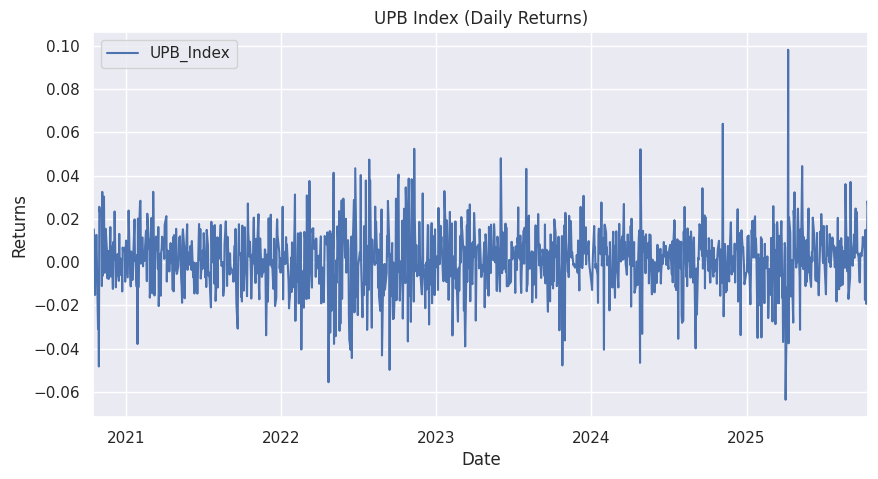

In [ ]:
# Suma de retornos y creación del índice de mercado
sum_return = max_sr_rts.sum(axis=1)
market_rts = pd.DataFrame(sum_return)
market_rts.columns = ['UPB_Index']

# Graficar con límites de fecha ajustados
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(market_rts.index, market_rts['UPB_Index'], label='UPB_Index')

# Ajuste del rango de fechas (según tu dataset)
ax.set_xlim(pd.to_datetime('2020-10-15'), pd.to_datetime('2025-10-15'))

# Etiquetas y formato
ax.set_xlabel('Date')
ax.set_ylabel('Returns')
ax.set_title('UPB Index (Daily Returns)')
ax.legend()
plt.grid(True)
plt.show()


In [ ]:
riskfree_rate=rf
ark.summary_stats_day(r=market_rts, riskfree_rate=riskfree_rate)

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
UPB_Index,0.28259,0.234161,0.031477,5.744642,0.022207,0.033443,1.039487,-0.298186


In [ ]:
ark.drawdown(sum_return).min()

,0
Wealth,939.494087
Previous Peak,1015.137609
Drawdown,-0.298186
